# Workshop: Building Gemma 3 from Scratch
## Notebook 2: Causal Masking (Global + Sliding Window)

**Estimated Time: 10 minutes**

In a decoder-only model like Gemma 3, when we predict the next token, we must ensure the model only uses information from the current and previous tokens. If the model can "see" the answer during training, it won't learn anything!

## Learning Objectives:
1. Understand the concept of Causal Masking.
2. Implement a triangular mask using `torch.triu`.
3. Learn about Gemma 3's **5:1 local/global layer interleaving** with sliding window.

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

seq_len = 12
sliding_window = 4  # Gemma 3 uses sliding_window=1024

Python version: 3.12.13 (main, Mar 10 2026, 18:15:41) [Clang 21.1.4 ]
PyTorch version: 2.5.1


## 1. The Global Causal Mask

We want a matrix where position $(i, j)$ is `True` (masked = cannot see) if token $i$ is NOT allowed to see token $j$. For causality, token $i$ can only see $j$ if $j \le i$.

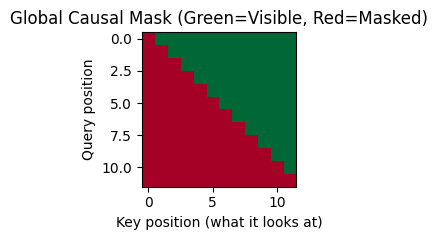

In [7]:
ones = torch.ones((seq_len, seq_len), dtype=torch.bool)
# Upper triangle (excluding diagonal) = future positions the model MUST NOT see
mask_global = torch.triu(ones, diagonal=1)

plt.figure(figsize=(6, 2.5))
plt.imshow(mask_global.float(), cmap='RdYlGn')
plt.title("Global Causal Mask (Green=Visible, Red=Masked)")
plt.xlabel("Key position (what it looks at)")
plt.ylabel("Query position")
plt.tight_layout()
plt.show()

## 2. Sliding Window Mask

Gemma 3 uses **Sliding Window Attention (SWA)**: a token only attends to a fixed number of previous tokens (the window). This massively reduces KV-cache memory for long sequences.

We need to mask out tokens that are too far in the past.

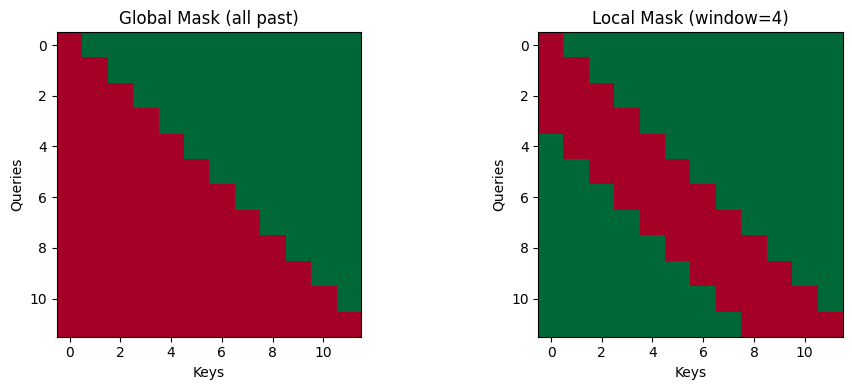

In [8]:
# For the sliding window: tokens too far in the past are masked
# With sliding_window=4, query i can see keys j where i-3 <= j <= i.
# Tokens at j <= i - sliding_window are masked out.
ones = torch.ones((seq_len, seq_len), dtype=torch.bool)

# far_past[i, j] = True if j <= i - sliding_window (key is too far back)
far_past = torch.tril(ones, diagonal=-sliding_window)

# Local attention = causal AND recent only
mask_local = mask_global | far_past

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask_global.float(), cmap='RdYlGn')
plt.title("Global Mask (all past)")
plt.xlabel("Keys")
plt.ylabel("Queries")

plt.subplot(1, 2, 2)
plt.imshow(mask_local.float(), cmap='RdYlGn')
plt.title(f"Local Mask (window={sliding_window})")
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.tight_layout()
plt.show()


## 3. Gemma 3: 5:1 Local/Global Alternation

Gemma 3 alternates layers: **5 local layers for every 1 global layer**.
- **Local layers** use sliding window (1024 tokens) -- tiny KV cache
- **Global layers** use full attention -- capture long-range dependencies
- This pattern starts with a **local layer** at position 0
- Reduces KV-cache memory from 60% to <15% of total inference memory

In [9]:
def get_layer_mask_type(layer_idx, sliding_window=1024):
    """Determine if layer is global or local.
    Gemma 3 pattern: layers 0-4 are local, layer 5 is global, repeat.
    """
    if layer_idx % 6 == 5:  # Every 6th layer (0-indexed) is global
        return "global"
    return "local"

# Show the pattern for 12 layers
pattern = [(i, get_layer_mask_type(i)) for i in range(12)]
print("Layer pattern (5 local : 1 global):")
for layer, mask_type in pattern:
    bar = "█" * (1024 if mask_type == "local" else 1) + "▌"
    print(f"  Layer {layer:2d}: {mask_type:6s} |{bar[:12]}| "
          + ("full context" if mask_type == "global" else f"window={1024}"))

print("\nEvery 6th layer is GLOBAL (full attention)")
print("Other 5 layers are LOCAL (sliding window=1024)")


Layer pattern (5 local : 1 global):
  Layer  0: local  |████████████| window=1024
  Layer  1: local  |████████████| window=1024
  Layer  2: local  |████████████| window=1024
  Layer  3: local  |████████████| window=1024
  Layer  4: local  |████████████| window=1024
  Layer  5: global |█▌| full context
  Layer  6: local  |████████████| window=1024
  Layer  7: local  |████████████| window=1024
  Layer  8: local  |████████████| window=1024
  Layer  9: local  |████████████| window=1024
  Layer 10: local  |████████████| window=1024
  Layer 11: global |█▌| full context

Every 6th layer is GLOBAL (full attention)
Other 5 layers are LOCAL (sliding window=1024)


## 4. Applying the Mask in Attention

In [11]:
scores = torch.randn(seq_len, seq_len)
masked_scores = scores.masked_fill(mask_global, float('-inf'))

print("Raw Scores (top-left 3x3):\n", scores[:3, :3].round(decimals=3))
print("\nMasked Scores (top-left 3x3):\n", masked_scores[:3, :3].round(decimals=3))
# Note: masked positions become -inf, so softmax gives 0.0

weights = torch.softmax(masked_scores, dim=-1)
print("\nAttention Weights (zeros in upper triangle):\n", weights[:3, :3].round(decimals=5))
print("Each row sums to:", weights.sum(dim=-1))

Raw Scores (top-left 3x3):
 tensor([[ 0.4450,  0.3010,  0.2670],
        [-0.9480, -1.8380,  0.8420],
        [-0.1680,  1.5370, -1.2390]])

Masked Scores (top-left 3x3):
 tensor([[ 0.4450,    -inf,    -inf],
        [-0.9480, -1.8380,    -inf],
        [-0.1680,  1.5370, -1.2390]])

Attention Weights (zeros in upper triangle):
 tensor([[1.0000, 0.0000, 0.0000],
        [0.7090, 0.2910, 0.0000],
        [0.1461, 0.8038, 0.0501]])
Each row sums to: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000])


## Exercise:
Create a function `get_mixed_mask(seq_len, sliding_window)` that returns both global and local masks, plus a function `apply_mask(scores, mask_type, sliding_window)` that applies the right mask based on layer type.

In [ ]:
def get_mixed_mask(seq_len, sliding_window=1024):
    """Return both global and local masks for Gemma 3."""
    ones = torch.ones((seq_len, seq_len), dtype=torch.bool)

    # Global mask: upper triangle (future tokens masked)
    mask_global = torch.triu(ones, diagonal=1)

    # Local mask: also mask keys that are more than sliding_window steps in the past
    far_past = torch.tril(ones, diagonal=-sliding_window)
    mask_local = mask_global | far_past

    return mask_global, mask_local

mask_g, mask_l = get_mixed_mask(seq_len, sliding_window)
assert torch.equal(mask_g, mask_global)
print("✅ get_mixed_mask works correctly!")
print(f"Global mask total masked: {mask_g.sum().item()}")
print(f"Local mask total masked: {mask_l.sum().item()}")


## Key Takeaway

Gemma 3 uses **5 local layers + 1 global layer** pattern:
- **Local layers**: attend to recent window (1024 tokens) + causal → tiny KV cache
- **Global layers**: attend to everything → long-range understanding
- This dramatically reduces inference memory while maintaining quality